#### 1 - Considere a base de concreto da UCI. 

Ajuste um modelo de regressão para predizer a variável y (Concrete compressive strength). 

Compare o coeficiente R2 obtido através de regressão linear múltipla, Lasso e ridge regression. 

Para os métodos Lasso e ridge regression, faça um gráfico de $\alpha \times$ R2 como foi feito nos exemplos anteriores. 

Use o código a seguir.

In [1]:
# !pip install ucimlrepo
from ucimlrepo import fetch_ucirepo
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# fetch dataset
concrete_compressive_strength = fetch_ucirepo(id=165)

# data (as pandas dataframes)
X = concrete_compressive_strength.data.features
y = concrete_compressive_strength.data.targets

# metadata
print(concrete_compressive_strength.metadata)

# variable information
print(concrete_compressive_strength.variables)

{'uci_id': 165, 'name': 'Concrete Compressive Strength', 'repository_url': 'https://archive.ics.uci.edu/dataset/165/concrete+compressive+strength', 'data_url': 'https://archive.ics.uci.edu/static/public/165/data.csv', 'abstract': 'Concrete is the most important material in civil engineering. The concrete compressive strength is a highly nonlinear function of age and ingredients. ', 'area': 'Physics and Chemistry', 'tasks': ['Regression'], 'characteristics': ['Multivariate'], 'num_instances': 1030, 'num_features': 8, 'feature_types': ['Real'], 'demographics': [], 'target_col': ['Concrete compressive strength'], 'index_col': None, 'has_missing_values': 'no', 'missing_values_symbol': None, 'year_of_dataset_creation': 1998, 'last_updated': 'Sun Feb 11 2024', 'dataset_doi': '10.24432/C5PK67', 'creators': ['I-Cheng Yeh'], 'intro_paper': {'ID': 383, 'type': 'NATIVE', 'title': 'Modeling of strength of high-performance concrete using artificial neural networks', 'authors': 'I. Yeh', 'venue': 'C


R2 da Regressão Linear Múltipla: 0.6276
Melhor R2 do Lasso: 0.6276 (com alpha = 0.0100)
Melhor R2 do Ridge: 0.6276 (com alpha = 0.9326)


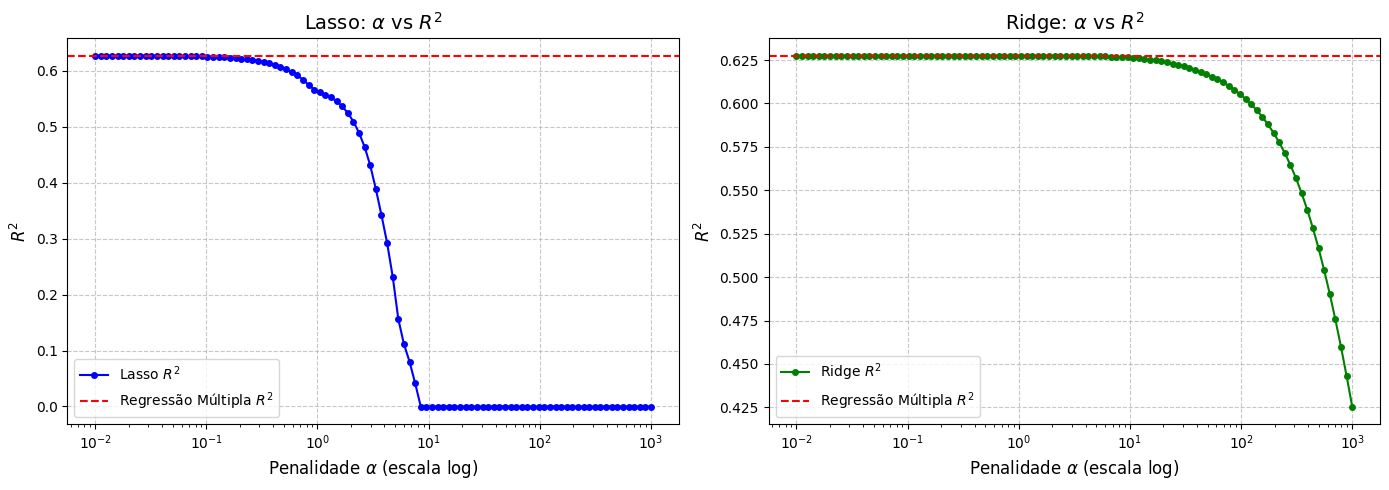

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from ucimlrepo import fetch_ucirepo
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Lasso, Ridge
from sklearn.metrics import r2_score

y = y.values.ravel() 

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

lm = LinearRegression()
lm.fit(X_train_scaled, y_train)
y_pred_lm = lm.predict(X_test_scaled)
r2_lm = r2_score(y_test, y_pred_lm)

print(f"\nR2 da Regressão Linear Múltipla: {r2_lm:.4f}")

alphas = np.logspace(-2, 3, 100)

vR2_lasso = []
vR2_ridge = []

for alpha in alphas:
    lasso = Lasso(alpha=alpha, max_iter=10000)
    lasso.fit(X_train_scaled, y_train)
    y_pred_lasso = lasso.predict(X_test_scaled)
    vR2_lasso.append(r2_score(y_test, y_pred_lasso))
    
    ridge = Ridge(alpha=alpha)
    ridge.fit(X_train_scaled, y_train)
    y_pred_ridge = ridge.predict(X_test_scaled)
    vR2_ridge.append(r2_score(y_test, y_pred_ridge))

print(f"Melhor R2 do Lasso: {max(vR2_lasso):.4f} (com alpha = {alphas[np.argmax(vR2_lasso)]:.4f})")
print(f"Melhor R2 do Ridge: {max(vR2_ridge):.4f} (com alpha = {alphas[np.argmax(vR2_ridge)]:.4f})")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Lasso
ax1.plot(alphas, vR2_lasso, '-bo', label='Lasso $R^2$', markersize=4)
ax1.axhline(r2_lm, color='red', linestyle='--', label='Regressão Múltipla $R^2$')
ax1.set_xscale('log') # Escala logarítmica no eixo X facilita a visualização
ax1.set_xlabel(r"Penalidade $\alpha$ (escala log)", fontsize=12)
ax1.set_ylabel("$R^2$", fontsize=12)
ax1.set_title("Lasso: $\\alpha$ vs $R^2$", fontsize=14)
ax1.legend()
ax1.grid(True, linestyle='--', alpha=0.7)

# Ridge
ax2.plot(alphas, vR2_ridge, '-go', label='Ridge $R^2$', markersize=4)
ax2.axhline(r2_lm, color='red', linestyle='--', label='Regressão Múltipla $R^2$')
ax2.set_xscale('log')
ax2.set_xlabel(r"Penalidade $\alpha$ (escala log)", fontsize=12)
ax2.set_ylabel("$R^2$", fontsize=12)
ax2.set_title("Ridge: $\\alpha$ vs $R^2$", fontsize=14)
ax2.legend()
ax2.grid(True, linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

#### 2 - Determine as variáveis que mais influenciam a variável y (Concrete compressive strength).

Melhor Alpha do Lasso utilizado: 0.0100

                  Var         R²      Lasso
5    Coarse Aggregate   1.405196   1.206042
6      Fine Aggregate   1.950529   1.705504
4    Superplasticizer   1.852126   1.831567
3               Water  -2.882597  -3.073035
2             Fly Ash   5.254578   5.028835
7                 Age   7.037434   7.013386
1  Blast Furnace Slag   9.434456   9.174262
0              Cement  12.788413  12.524909


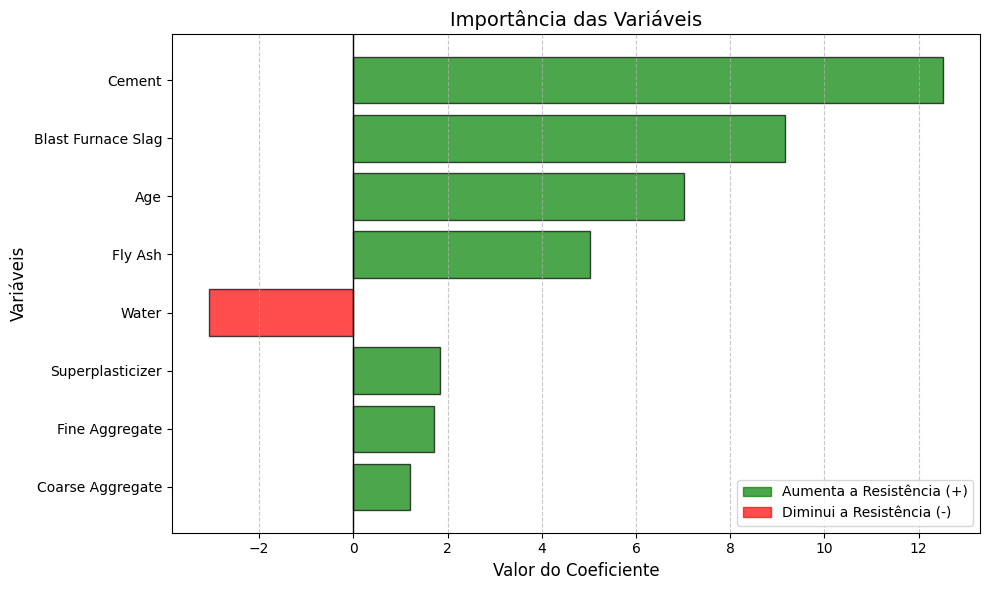

In [3]:
feature_names = concrete_compressive_strength.data.features.columns

best_alpha_lasso = alphas[np.argmax(vR2_lasso)]
best_lasso = Lasso(alpha=best_alpha_lasso, max_iter=10000)
best_lasso.fit(X_train_scaled, y_train)

df_importancia = pd.DataFrame({
    'Var': feature_names,
    'R²': lm.coef_,
    'Lasso': best_lasso.coef_
})

df_importancia['Importância Absoluta'] = np.abs(df_importancia['Lasso'])
df_importancia = df_importancia.sort_values(by='Importância Absoluta', ascending=True)

print(f"Melhor Alpha do Lasso utilizado: {best_alpha_lasso:.4f}\n")
print(df_importancia[['Var', 'R²', 'Lasso']])

plt.figure(figsize=(10, 6))

cores = ['green' if coef > 0 else 'red' for coef in df_importancia['Lasso']]

plt.barh(df_importancia['Var'], df_importancia['Lasso'], color=cores, edgecolor='black', alpha=0.7)

plt.axvline(0, color='black', linewidth=1)
plt.title('Importância das Variáveis', fontsize=14)
plt.xlabel('Valor do Coeficiente', fontsize=12)
plt.ylabel('Variáveis', fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.7)

import matplotlib.patches as mpatches
green_patch = mpatches.Patch(color='green', label='Aumenta a Resistência (+)', alpha=0.7)
red_patch = mpatches.Patch(color='red', label='Diminui a Resistência (-)', alpha=0.7)
plt.legend(handles=[green_patch, red_patch], loc='lower right')

plt.tight_layout()
plt.show()

#### 3 - Considere os dados gerados com o código a seguir. Usando regularização, ajuste o grau do polinômio que define o modelo mais adequado.

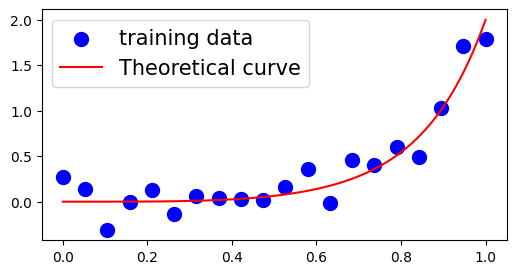

In [4]:
import numpy as np
from matplotlib import pyplot as plt
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.linear_model import Ridge, Lasso
from sklearn.pipeline import make_pipeline
from sklearn.metrics import mean_squared_error

np.random.seed(10)

#função para gerar os dados
def function(x):
    y = x**4 + x**9
    return y

# training set
N_train = 20
sigma = 0.2
x_train= np.linspace(0, 1,N_train)
y_train = function(x_train) + np.random.normal(0,sigma, N_train)
x_train = x_train.reshape(len(x_train), 1)

fig = plt.figure(figsize=(6, 3))
plt.scatter(x_train, y_train, facecolor="blue", edgecolor="b",
            s=100, label="training data")

# test set
N_test = 20
x_test=np.linspace(0, 1,N_test)
y_test = function(x_test) +  np.random.normal(0,sigma, N_test)
x_test = x_test.reshape(len(x_test), 1)

# Curva teorica
xt = np.linspace(0,1,100)
yt = function(xt)
plt.plot(xt,yt, '-r',  label="Theoretical curve")
plt.legend(fontsize=15)
plt.show(True)

Melhor Grau Ridge 0.1: 15
Melhor Grau Lasso 0.01: 6


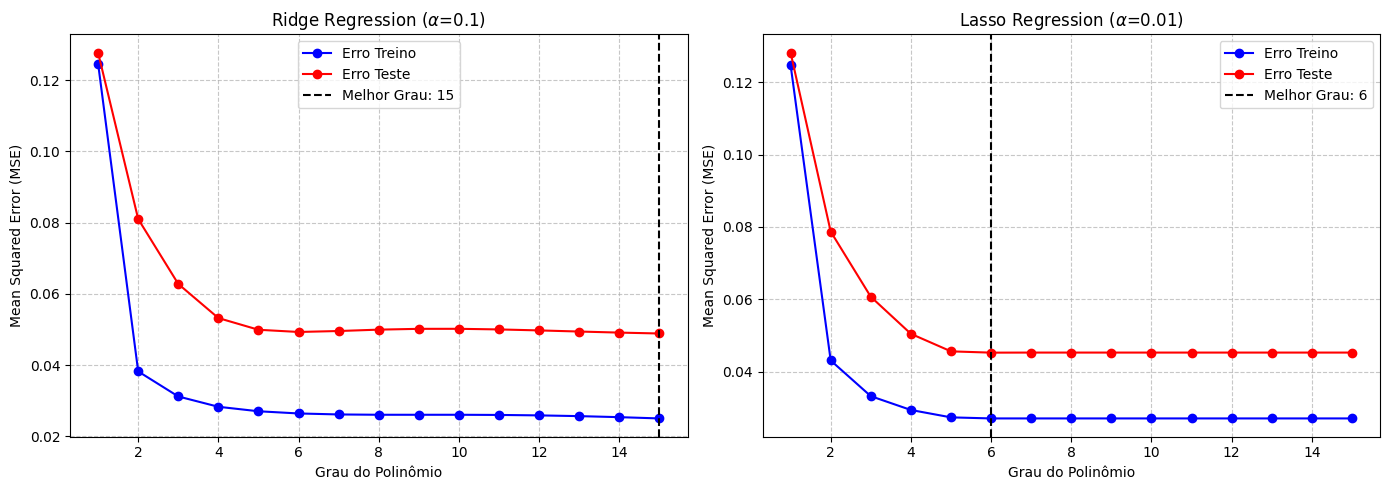

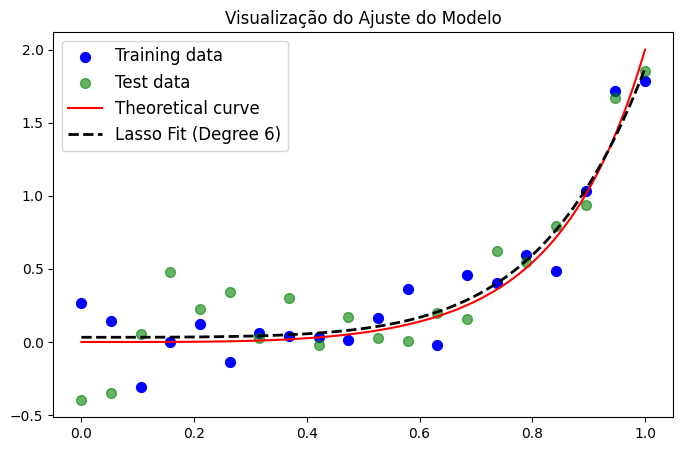

In [5]:
degrees = np.arange(1, 16)
mse_train_ridge, mse_test_ridge = [], []
mse_train_lasso, mse_test_lasso = [], []

alpha_ridge = 0.1 
alpha_lasso = 0.01

for degree in degrees:
    #Criar Polinômios -> Padronizar -> Ridge
    model_ridge = make_pipeline(PolynomialFeatures(degree), StandardScaler(), Ridge(alpha=alpha_ridge))
    model_ridge.fit(x_train, y_train)
    
    mse_train_ridge.append(mean_squared_error(y_train, model_ridge.predict(x_train)))
    mse_test_ridge.append(mean_squared_error(y_test, model_ridge.predict(x_test)))

    # --- LASSO ---
    model_lasso = make_pipeline(PolynomialFeatures(degree), StandardScaler(), Lasso(alpha=alpha_lasso, max_iter=100000))
    model_lasso.fit(x_train, y_train)
    
    mse_train_lasso.append(mean_squared_error(y_train, model_lasso.predict(x_train)))
    mse_test_lasso.append(mean_squared_error(y_test, model_lasso.predict(x_test)))

best_degree_ridge = degrees[np.argmin(mse_test_ridge)]
best_degree_lasso = degrees[np.argmin(mse_test_lasso)]

print(f"Melhor Grau Ridge {alpha_ridge}: {best_degree_ridge}")
print(f"Melhor Grau Lasso {alpha_lasso}: {best_degree_lasso}")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Plot Ridge
ax1.plot(degrees, mse_train_ridge, 'b-o', label='Erro Treino')
ax1.plot(degrees, mse_test_ridge, 'r-o', label='Erro Teste')
ax1.axvline(best_degree_ridge, color='k', linestyle='--', label=f'Melhor Grau: {best_degree_ridge}')
ax1.set_xlabel('Grau do Polinômio')
ax1.set_ylabel('Mean Squared Error (MSE)')
ax1.set_title(f'Ridge Regression ($\\alpha$={alpha_ridge})')
ax1.legend()
ax1.grid(True, linestyle='--', alpha=0.7)

# Plot Lasso
ax2.plot(degrees, mse_train_lasso, 'b-o', label='Erro Treino')
ax2.plot(degrees, mse_test_lasso, 'r-o', label='Erro Teste')
ax2.axvline(best_degree_lasso, color='k', linestyle='--', label=f'Melhor Grau: {best_degree_lasso}')
ax2.set_xlabel('Grau do Polinômio')
ax2.set_ylabel('Mean Squared Error (MSE)')
ax2.set_title(f'Lasso Regression ($\\alpha$={alpha_lasso})')
ax2.legend()
ax2.grid(True, linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 5))
plt.scatter(x_train, y_train, facecolor="blue", edgecolor="b", s=50, label="Training data")
plt.scatter(x_test, y_test, facecolor="green", edgecolor="g", s=50, label="Test data", alpha=0.6)

xt = np.linspace(0,1,100).reshape(-1, 1)
yt = function(xt)
plt.plot(xt, yt, '-r', label="Theoretical curve")

best_model = make_pipeline(PolynomialFeatures(best_degree_lasso), StandardScaler(), Lasso(alpha=alpha_lasso, max_iter=100000))
best_model.fit(x_train, y_train)
plt.plot(xt, best_model.predict(xt), '--k', linewidth=2, label=f"Lasso Fit (Degree {best_degree_lasso})")

plt.legend(fontsize=12)
plt.title("Visualização do Ajuste do Modelo")
plt.show()